<img style="float: right;" src="https://www.h-ka.de/typo3conf/ext/in2template/Resources/Public/Images/Icons/Favicons/favicon-256x256.png">

# Multiclass Support Vector Machine (MSVM) and Optimization exercise 

In this exercise you will:
    
- implement a fully-vectorized **loss function** for the SVM
- implement the fully-vectorized expression for its **analytic gradient**
- **check your implementation** using numerical gradient
- use a validation set to **tune the learning rate and regularization** strength
- **optimize** the loss function with **SGD**
- **visualize** the final learned weights

The original code for this exercise was published as an assignment in the [CS231n](http://cs231n.stanford.edu/index.html) course at Uni Standford. The code was modified to fit the syllabus for the lecture "[Neuronale Netze in Bildverarbeitung](https://www.h-ka.de/fileadmin/Hochschule_Karlsruhe_HKA/Informationsmaterialien/HKA_FK-EIT_Sem7_NeuronaleNetze_01.pdf)" at HKA.

## Student Details:

- FirstName: Thomas
- LastName: Mustermann
- MatriculationNumber: 12345
----------

To make it clear, we've a fully connected network consisting of an input layer $x_i$ and class score $s_i$.

The class score $s_i$ is calculated using the weights $W$ and the input $x_i$. The network for this looks like this:

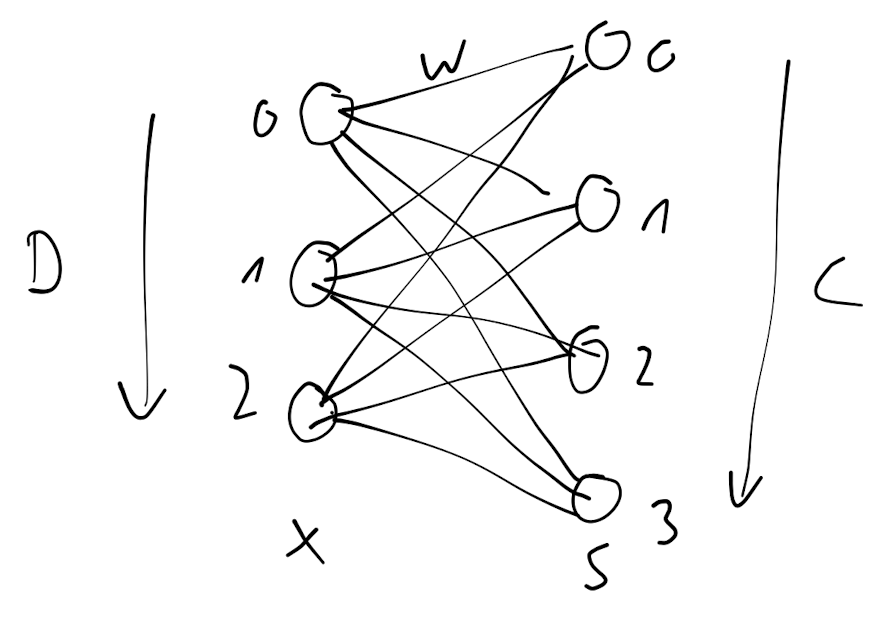

- $x_i$ is of type [1xD]
- $W$ is of type [DxC]
- $s_i$ is of type [1xC]

Hence $s_i$ can be calculated using the matrix multiplication $s_i=x_i \cdot W$.

In $s_i$ all scores for all classes are calculated for the i-th image. 
Later we'll use the scores to predict the class of an image (classification). 
This will be done be selecting the class that corresponds to the highest score.

### Trick 1: More than one image at a time

If we want to calculate more than one image at a time, lets say N images, we can extend the first dimension of $x$, then we get:
- $X$ is of type [NxD]
- $W$ is of type [DxC]
- $S$ is of type [NxC]

- D is the number of pixels,
- C the number of classes and 
- N the number of images.

This means all scores for all classes and for all images can be calculated using the formular: $S=X \cdot W$

By selecting the **class** that corresponts to the **highest score** for each image we could **predict** each label for each image. <span style="color:red">**This means we want the score of the correct class to be the higher than the other scores!**</span>

In [ ]:
# Run some setup code for this notebook.

import random
import numpy as np
from EITB712M.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

# This is a bit of magic to make matplotlib figures appear inline in the notebook
# rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

## CIFAR-10 Data Loading and Preprocessing

In [ ]:
cifar10_dir = 'datasets/cifar-10-batches-py'

import os.path

# Get the CIFAR10 data if not present
if os.path.isdir(cifar10_dir):
    print ("CIFAR10 folder exist, skipping download. If you encouter errors, load and unpack the data manually.")
else:
    !mkdir datasets/
    !cd datasets/ && wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz -O cifar-10-python.tar.gz && tar -xzvf cifar-10-python.tar.gz && rm cifar-10-python.tar.gz 

In [ ]:
# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

In [ ]:
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [ ]:
# Split the data into train, val, and test sets. In addition we will
# create a small development set as a subset of the training data;
# we can use this for development so our code runs faster.
num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

# Our validation set will be num_validation points from the original training set.
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# Our training set will be the first num_train points from the original training set.
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# We will also make a development set, which is a small subset of the training set.
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# We use the first num_test points of the original test set as our test set.
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

In [ ]:
# Preprocessing: reshape the image data into rows
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# As a sanity check, print out the shapes of the data
print('Training data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)
print('dev data shape: ', X_dev.shape)

In [ ]:
# Preprocessing: normalization, subtract the mean image
# first: compute the image mean based on the training data
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) # print a few of the elements
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) # visualize the mean image
plt.show()

# second: subtract the mean image from train and test data
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# third: append the bias dimension of ones (i.e. bias trick) so that our SVM
# only has to worry about optimizing a single weight matrix W.
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

## Loss calculation using MSVM

- <span style="color:blue">**Your code for this section will all be written inside `EITB712M/classifiers/linear_svm.py`.**</span>

The loss is an objective measure to judge the prediction accuracy of our network. 
Therefore we check if the score of the true class is the highest (+$\Delta$) for each image. 
This can be done using the MSVM loss function $L_i$ for each image $i$: 

$L_i =  \sum_{j\neq y_i} \left[ \max(0, s_j - s_{y_i} + \Delta) \right]$

Here $y_i$ denotes the true class and $j$ denotes all incorrect classes. 
As you can see the loss $L_i$ will be higher the more the incorrect classes are higher than the true class. 

For a set of `N` images the loss can be calculated using the mean value over the images:

$L = \frac{1}{N} \sum_i \sum_{j\neq y_i} \left[ \max(0, s_j - s_{y_i} + \Delta) \right]$

If we find a set of weights $W$ that result in a loss of $0$, than all scaled weights with $a \cdot W$, $a>1$ will result also in a loss of $0$. 
This means we do not have a single right solution. 
To resolve this unpleasend property, a regularization $R(W)$ is defined. 
This regularization, e.g. the sum over all squares of the weights, defines the desired unique optimum solution.
$\lamda$ is used to set the strenght of the regularization.

$L = \frac{1}{N} \sum_i \sum_{j\neq y_i} \left[ \max(0, s_j - s_{y_i} + \Delta) \right] + \lambda R(W)$

- With $y_i$ the true class and $j$ the incorrect classes. 
- For the regularization we will use the sum of the squares of the weights.

<span style="color:blue">**Have a look into the file `EITB712M/classifiers/linear_svm.py`. As you can see, we have prefilled the function `svm_loss_naive` which uses for loops to evaluate the multiclass SVM loss function. The gradient `grad` returned from the function above is right now all zero.**</span>

In [ ]:
# Evaluate the naive implementation of the loss we provided for you:
from EITB712M.classifiers.linear_svm import svm_loss_naive
import time

# generate a random SVM weight matrix of small numbers
W = np.random.randn(3073, 10) * 0.0001 

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

## Gradient calculation 

At the beginning our prediction will be quite worse, as we need to adjust our weights to calculate the heighest score for the true class.
The adjustment of the weights is called optimization. 
The optimization is done be calculating the gradient of the loss $L$ depending on the weights $W$.
For simplification we will only look at gradient calculation for $L_i$, as the gradient for $L$ is just sum of the mean value of $L_i$ and the derivative of the regularization. 
This means we want to derive the function $L_i$ using the matrix $W$, what is the partial derivative of $L_i$ for each element in $W$:

$ \frac{\partial L_i}{\partial W} 
= \left( \begin{matrix}  \frac{\partial L_i}{\partial w_{1,1}} & \dots  & \frac{\partial L_i}{\partial w_{1,C}}\\ 
   \vdots  & \ddots & \vdots \\
\frac{\partial L_i}{\partial w_{D,1}} & \dots  & \frac{\partial L_i}{\partial w_{D,C}} \end{matrix} \right) $

As $W$ is of type [DxC], $ \frac{\partial L_i}{\partial W}$ will be of the same type.

- <span style="color:green">**Look ahead: For the optimization process we later will calculate the new weights $w_{n+1}$ based on the gradient and the current weights:**</span>

$W_{n+1}=W_n - \alpha \frac{\partial L}{\partial W}$ 

with $\alpha$ the learning rate, a hyperparamter that needs to be choosen very carefully.

- <span style="color:blue">**Now implement the gradient for the MSVM loss function inside the function `svm_loss_naive`. You will find it helpful to interleave your new code inside the existing function.**</span>

- <span style="color:green">**Look ahead: A negative gradient will result in higher weights and vice versa. This means we can expect that the true class scores will get higher while the incorrect class scores will get lower.**</span>

To check that you have correctly implemented the gradient correctly, you can numerically estimate the gradient of the loss function and compare the numeric estimate to the gradient that you computed. We have provided code that does this for you:

In [ ]:
# Once you've implemented the gradient, recompute it with the code below
# and gradient check it with the function we provided for you

# Compute the loss and its gradient at W.
loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.0)

# Numerically compute the gradient along several randomly chosen dimensions, and
# compare them with your analytically computed gradient. The numbers should match
# almost exactly along all dimensions.
from EITB712M.gradient_check import grad_check_sparse
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

# do the gradient check once again with regularization turned on
# you didn't forget the regularization gradient did you?
loss, grad = svm_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

**Inline Question 1**

It is possible that once in a while a dimension in the gradcheck will not match exactly. What could such a discrepancy be caused by? Is it a reason for concern? What is a simple example in one dimension where a gradient check could fail? How would change the margin affect of the frequency of this happening? *Hint: the SVM loss function is not strictly speaking differentiable*

$\color{blue}{\textit Your Answer:}$ *fill this in.*  

## Vectorization of the Loss

For example, using two images with $y=(2,3)$ your score matrix could look like:

$ S = \left( \begin{matrix} 1 & 1 & -2 & 1 & 1 & 1 & 1 & 1 & 1 & 1 \\ 
                            2 & 2 & 2 & -3 & 2 & 2 & 2 & 2 & 2 & 2 \end{matrix} \right) $

Then the correct class scores are at (0,2) and (1,3), intentionally shown with the worst scores for all classes in the example.

In Python you can get the correct class score by using:<br>
`correct_class_scores = scores[np.arange(num_train), y].reshape(num_train,1)`

With the correct class scores you are able to calculate the classes in the matrix $M$ that haven't met the margin requirement. 
For this you can use broadcasting, the procedure is similar to the broadcasting example from the lecture. The matrix $M$ should look like 

$ M = m_{i,k}=\left( \begin{matrix} m_{1,1} & \dots  & m_{1,C}\\ 
                            \vdots  & \ddots & \vdots \\
                            m_{N,1} & \dots  & m_{N,C} \end{matrix} \right) $
                            
with 

$m_{i,k}= \begin{cases}
    \max(0, s_{i,k} - s_{i,y_i} + \Delta), & \text{if }  k \neq y_i \\
    0,              & \text{otherwise}
\end{cases}$

Adding up all the margins results in the loss. 

Don't forget to normalize the loss by the number of images and add the regularization to the loss. 



In [ ]:
# Next implement the function svm_loss_vectorized; for now only compute the loss;
# we will implement the gradient in a moment.
tic = time.time()
loss_naive, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from EITB712M.classifiers.linear_svm import svm_loss_vectorized
tic = time.time()
loss_vectorized, _ = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))

# The losses should match but your vectorized implementation should be much faster.
print('difference: %f' % (loss_naive - loss_vectorized))

## Vectorization of the Gradient

The gradient could be a bit more tricky, but let's try to get there step by step. 

As we have seen above, we want to calculate a matrix for the gradient $\nabla_{w} L$, with the size [D, C] as we want it to be the same size than the weight matrix, so we can subtract is later in the optimization. 

The gradient for the true classes is the **sum** of the classes that haven't met the margin requirement multiplied with the image $x_i$ and simply $x_i$ for the incorrect classes, if they haven't met the margin requirement.

The classes that haven't met the requirement have been already calculated in the matrix $M$. 
It should have a size of [N, C] e.g. 500x10 if you're using the dev set. 

For for the vectorization we define a matrix $V$ with

$ V = v_{i,k}=\left( \begin{matrix} v_{1,1} & \dots  & v_{1,C}\\ 
                            \vdots  & \ddots & \vdots \\
                            v_{N,1} & \dots  & v_{N,C} \end{matrix} \right) $
                            
with 

$v_{i,k}= \begin{cases}
    1, & \text{if }  m_{i,k} > 0 \\
    0, & \text{otherwise}
\end{cases}$

The matrix $V$ has all the classes that haven't met the margin requirement marked with $1$.
The sum over all classes gives us a vector $d$ of size [N,1] the number of classes that haven't met the margin requirement. The elements of $d$ needs to be subtracted from the matrix $V$ at each position of the true classes. In Python this can be done using:

`V[np.arange(N),y ] -= d`

This means in the matrix $V$ we then have the values of $\frac{\partial L_i}{\partial S}$.

Justin Johnson has written a document about [Derivatives, Backpropagation, and Vectorization](http://cs231n.stanford.edu/handouts/derivatives.pdf)
In this document he shows that 
- $\frac{\partial L_i}{\partial W}=\frac{\partial L_i}{\partial S} \cdot \frac{\partial S}{\partial W}$ can be calculated using a matrix multiplication

- $\frac{\partial L_i}{\partial W} = X^T \cdot \frac{\partial L_i}{\partial S}$, in our case: $\frac{\partial L_i}{\partial W} = X^T \cdot V$

In [ ]:
# Complete the implementation of svm_loss_vectorized, and compute the gradient
# of the loss function in a vectorized way.

# The naive implementation and the vectorized implementation should match, but
# the vectorized version should still be much faster.
tic = time.time()
_, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

# The loss is a single number, so it is easy to compare the values computed
# by the two implementations. The gradient on the other hand is a matrix, so
# we use the Frobenius norm to compare them.
difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

### Stochastic Gradient Descent

We now have vectorized and efficient expressions for the loss, the gradient and our gradient matches the numerical gradient. We are therefore ready to do SGD to minimize the loss. 

<span style="color:blue">**Implement the weight update.</span>**
Your code for this part will be written inside `EITB712M/classifiers/linear_classifier.py`.

Remember the weight update is calculated as follows: 

$W_{n+1}=W_n-\alpha \nabla_w L$

In [ ]:
# In the file linear_classifier.py, implement SGD in the function
# LinearClassifier.train() and then run it with the code below.
from EITB712M.classifiers.linear_classifier import LinearSVM
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=2500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

In [ ]:
# A useful debugging strategy is to plot the loss as a function of
# iteration number:
plt.plot(loss_hist)
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

In [ ]:
# Write the LinearSVM.predict function and evaluate the performance on both the
# training and validation set
y_train_pred = svm.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = svm.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

In [ ]:
# Now the validation set is used to tune the hyperparameters (regularization strength and
# learning rate). You should experiment with different ranges for the learning
# rates and regularization strengths; if you are careful you should be able to
# get a classification accuracy of about 0.39 on the validation set.

# Note: you may see runtime/overflow warnings during hyper-parameter search. 
# This may be caused by extreme values, and is not a bug.

# results is dictionary mapping tuples of the form
# (learning_rate, regularization_strength) to tuples of the form
# (training_accuracy, validation_accuracy). The accuracy is simply the fraction
# of data points that are correctly classified.
results = {}
best_val = -1   # The highest validation accuracy that we have seen so far.
best_svm = None # The LinearSVM object that achieved the highest validation rate.

# Provided as a reference. You may or may not want to change these hyperparameters
learning_rates = [5e-8, 1e-7, 3e-7]
regularization_strengths = [1.5e4, 1.75e4, 2e4, 2.25e4, 2.5e4, 3.5e4, 4e4]

# Obtain all possible combinations
grid_search = [ (lr,rg) for lr in learning_rates for rg in regularization_strengths ]

for lr, rg in grid_search:
    # Create a new SVM instance
    svm = LinearSVM()
    # Train the model with current parameters
    train_loss = svm.train(X_train, y_train, learning_rate=lr, reg=rg,
                      num_iters=1500, verbose=False)
    # Predict values for training set
    y_train_pred = svm.predict(X_train)
    # Calculate accuracy
    train_accuracy = np.mean(y_train_pred == y_train)
    # Predict values for validation set
    y_val_pred = svm.predict(X_val)
    # Calculate accuracy
    val_accuracy = np.mean(y_val_pred == y_val)
    # Save results
    results[(lr,rg)] = (train_accuracy, val_accuracy)
    if best_val < val_accuracy:
        best_val = val_accuracy
        best_svm = svm

# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))
    
print('best validation accuracy achieved during cross-validation: %f' % best_val)

In [ ]:
# Visualize the cross-validation results
import math
import pdb

# pdb.set_trace()

x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# plot training accuracy
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 training accuracy')

# plot validation accuracy
colors = [results[x][1] for x in results] # default size of markers is 20
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.show()

In [ ]:
# Evaluate the best svm on test set
y_test_pred = best_svm.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('linear SVM on raw pixels final test set accuracy: %f' % test_accuracy)

In [ ]:
# Visualize the learned weights for each class.
# Depending on your choice of learning rate and regularization strength, these may
# or may not be nice to look at.
w = best_svm.W[:-1,:] # strip out the bias
w = w.reshape(32, 32, 3, 10)
w_min, w_max = np.min(w), np.max(w)
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)
      
    # Rescale the weights to be between 0 and 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])

**Inline question 2**

Describe what your visualized SVM weights look like, and offer a brief explanation for why they look they way that they do.

$\color{blue}{\textit Your Answer:}$ *fill this in*  
